In [1]:
# ── CELL 1: Install & check GPU ───────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q'], check=True)

import torch
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('NO GPU — go to Settings -> Accelerator -> GPU T4 x2')
print('[OK] Cell 1 done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 107.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

PyTorch: 2.10.0+cu128
GPU: Tesla T4
[OK] Cell 1 done


In [2]:
# ── CELL 2: Find dataset and split into train/val/test ────────────
import shutil, random
from pathlib import Path

EXPECTED_CLASSES = ['Clean', 'Dusty', 'Bird-drop',
                    'Electrical-damage', 'Physical-Damage', 'Snow-Covered']

INPUT_DIR = Path('/kaggle/input')
WORK_DIR  = Path('/kaggle/working/surface_defects_split')

# Find the folder containing the 6 class subfolders (search up to 2 levels deep)
def find_dataset_root(base):
    if all((base / c).exists() for c in EXPECTED_CLASSES):
        return base
    for sub in base.iterdir():
        if sub.is_dir() and all((sub / c).exists() for c in EXPECTED_CLASSES):
            return sub
    for sub in base.rglob('*'):
        if sub.is_dir() and all((sub / c).exists() for c in EXPECTED_CLASSES):
            return sub
    return None

src = None
for d in INPUT_DIR.iterdir():
    found = find_dataset_root(d)
    if found:
        src = found
        break

if src is None:
    raise FileNotFoundError(
        f'Could not find folders {EXPECTED_CLASSES} under /kaggle/input/\n'
        'Make sure you added the dataset: + Add Data -> search solar-panel-images -> Add'
    )

print(f'Found dataset at: {src}')

# Split 80/10/10
random.seed(42)
for split in ['train', 'val', 'test']:
    for cls in EXPECTED_CLASSES:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

print('\nSplitting dataset:')
class_counts = {}
for cls in EXPECTED_CLASSES:
    cls_dir = src / cls
    images = (list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) +
              list(cls_dir.glob('*.png')))
    random.shuffle(images)
    n = len(images)
    n_train, n_val = int(n*0.8), int(n*0.1)
    splits = {'train': images[:n_train],
             'val':   images[n_train:n_train+n_val],
             'test':  images[n_train+n_val:]}
    for split, files in splits.items():
        for f in files:
            shutil.copy2(f, WORK_DIR / split / cls / f.name)
    class_counts[cls] = n
    print(f'  {cls:20s} {n:4d} total -> {len(splits["train"]):3d} train '
          f'{len(splits["val"]):3d} val {len(splits["test"]):3d} test')

total = sum(class_counts.values())
print(f'\nTotal: {total} images')

max_c, min_c = max(class_counts.values()), min(class_counts.values())
if min_c > 0 and max_c/min_c > 5:
    print(f'\n[WARN] Class imbalance: {max_c/min_c:.1f}:1 — model may favour bigger classes')

print(f'\n[OK] Cell 2 done — dataset ready at {WORK_DIR}')

Found dataset at: /kaggle/input/datasets/pythonafroz/solar-panel-images/Faulty_solar_panel

Splitting dataset:
  Clean                 185 total -> 148 train  18 val  19 test
  Dusty                 190 total -> 152 train  19 val  19 test
  Bird-drop             171 total -> 136 train  17 val  18 test
  Electrical-damage      90 total ->  72 train   9 val   9 test
  Physical-Damage        66 total ->  52 train   6 val   8 test
  Snow-Covered          105 total ->  84 train  10 val  11 test

Total: 807 images

[OK] Cell 2 done — dataset ready at /kaggle/working/surface_defects_split


In [3]:
# ── CELL 3: Train YOLOv8 classifier ───────────────────────────────
# Expected time: ~10-15 min on T4 (classification trains fast)
# Expected accuracy: 0.75-0.90 depending on class balance
from ultralytics import YOLO
import torch

if not torch.cuda.is_available():
    raise RuntimeError('No GPU! Settings -> Accelerator -> GPU T4 x2 -> Save')

DATA_DIR   = '/kaggle/working/surface_defects_split'
OUTPUT_DIR = '/kaggle/working/models'
RUN_NAME   = 'surface_defect_v1'

model = YOLO('yolov8n-cls.pt')   # nano classifier — small, fast, plenty for 6 classes

results = model.train(
    data=DATA_DIR,
    epochs=60,
    imgsz=224,            # classification uses smaller images than detection (640)
    batch=32,
    device=0,
    project=OUTPUT_DIR,
    name=RUN_NAME,
    patience=20,
    lr0=0.001,
    lrf=0.01,
    # Full color augmentation makes sense here (unlike thermal model)
    # since these are real RGB photos with varying outdoor lighting
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.3,
    degrees=15.0,
    fliplr=0.5,
    flipud=0.0,
    plots=True,
    save=True,
)

try:
    acc = results.results_dict.get('metrics/accuracy_top1', 0)
    print(f'\nTop-1 Accuracy: {acc:.4f}', end=' ')
    print('EXCELLENT' if acc>=0.85 else 'GOOD' if acc>=0.70 else 'FAIR')
except Exception:
    pass
print(f'Best weights: {OUTPUT_DIR}/{RUN_NAME}/weights/best.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/surface_defects_split, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,442,566 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/surface_defects_split/train... found 644 images in 6 classes ✅ 
val: /kaggle/working/surface_defects_split/val... found 79 images in 6 classes ✅ 
test: /kaggle/working/surface_defects_split/test... found 84 images in 6 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1874.0±1081.0 MB/s, size: 428.3 KB)
test: Scanning /kaggle/working/surface_defects_split/test... 84 images, 0 corrupt: 100% ━━━━━━━━━━━━ 84/84 173.6it/s 0.5s.4s
test: /kaggle/working/surface_defects_split/test/Dusty/Dust (17).jpg: corrupt JPEG restored and saved
test: /kaggle/working/surface_defects_split/test/Electrical-damage/Electrical (61).jpg: corrupt JPEG restored and saved
test: New cache created: /kaggle/working/surface_defects_split/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 6/6 2.

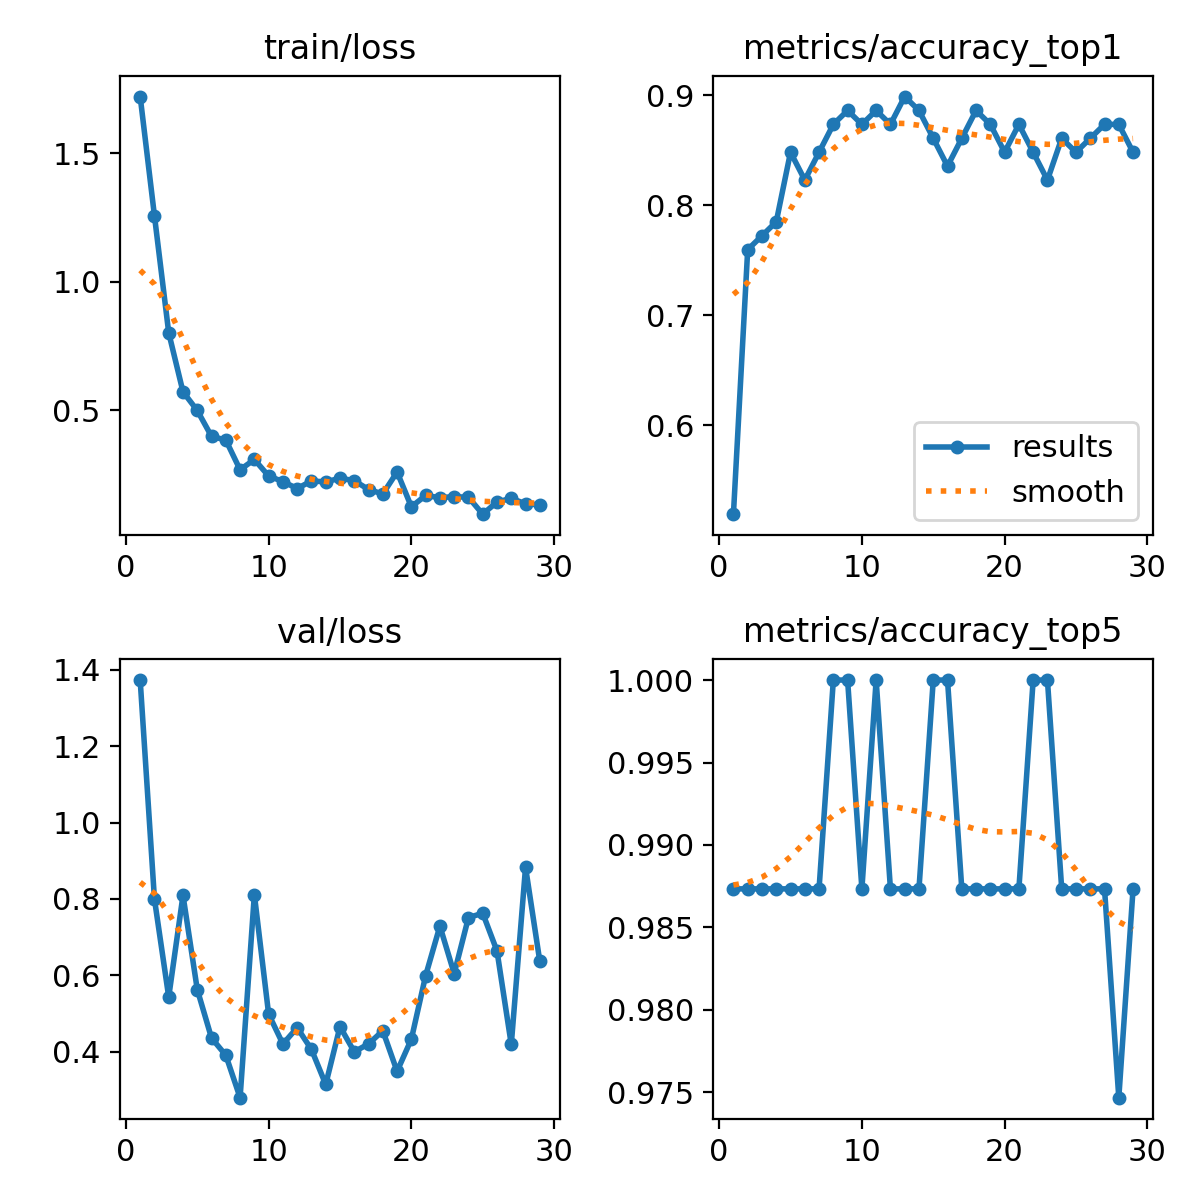


confusion_matrix.png:


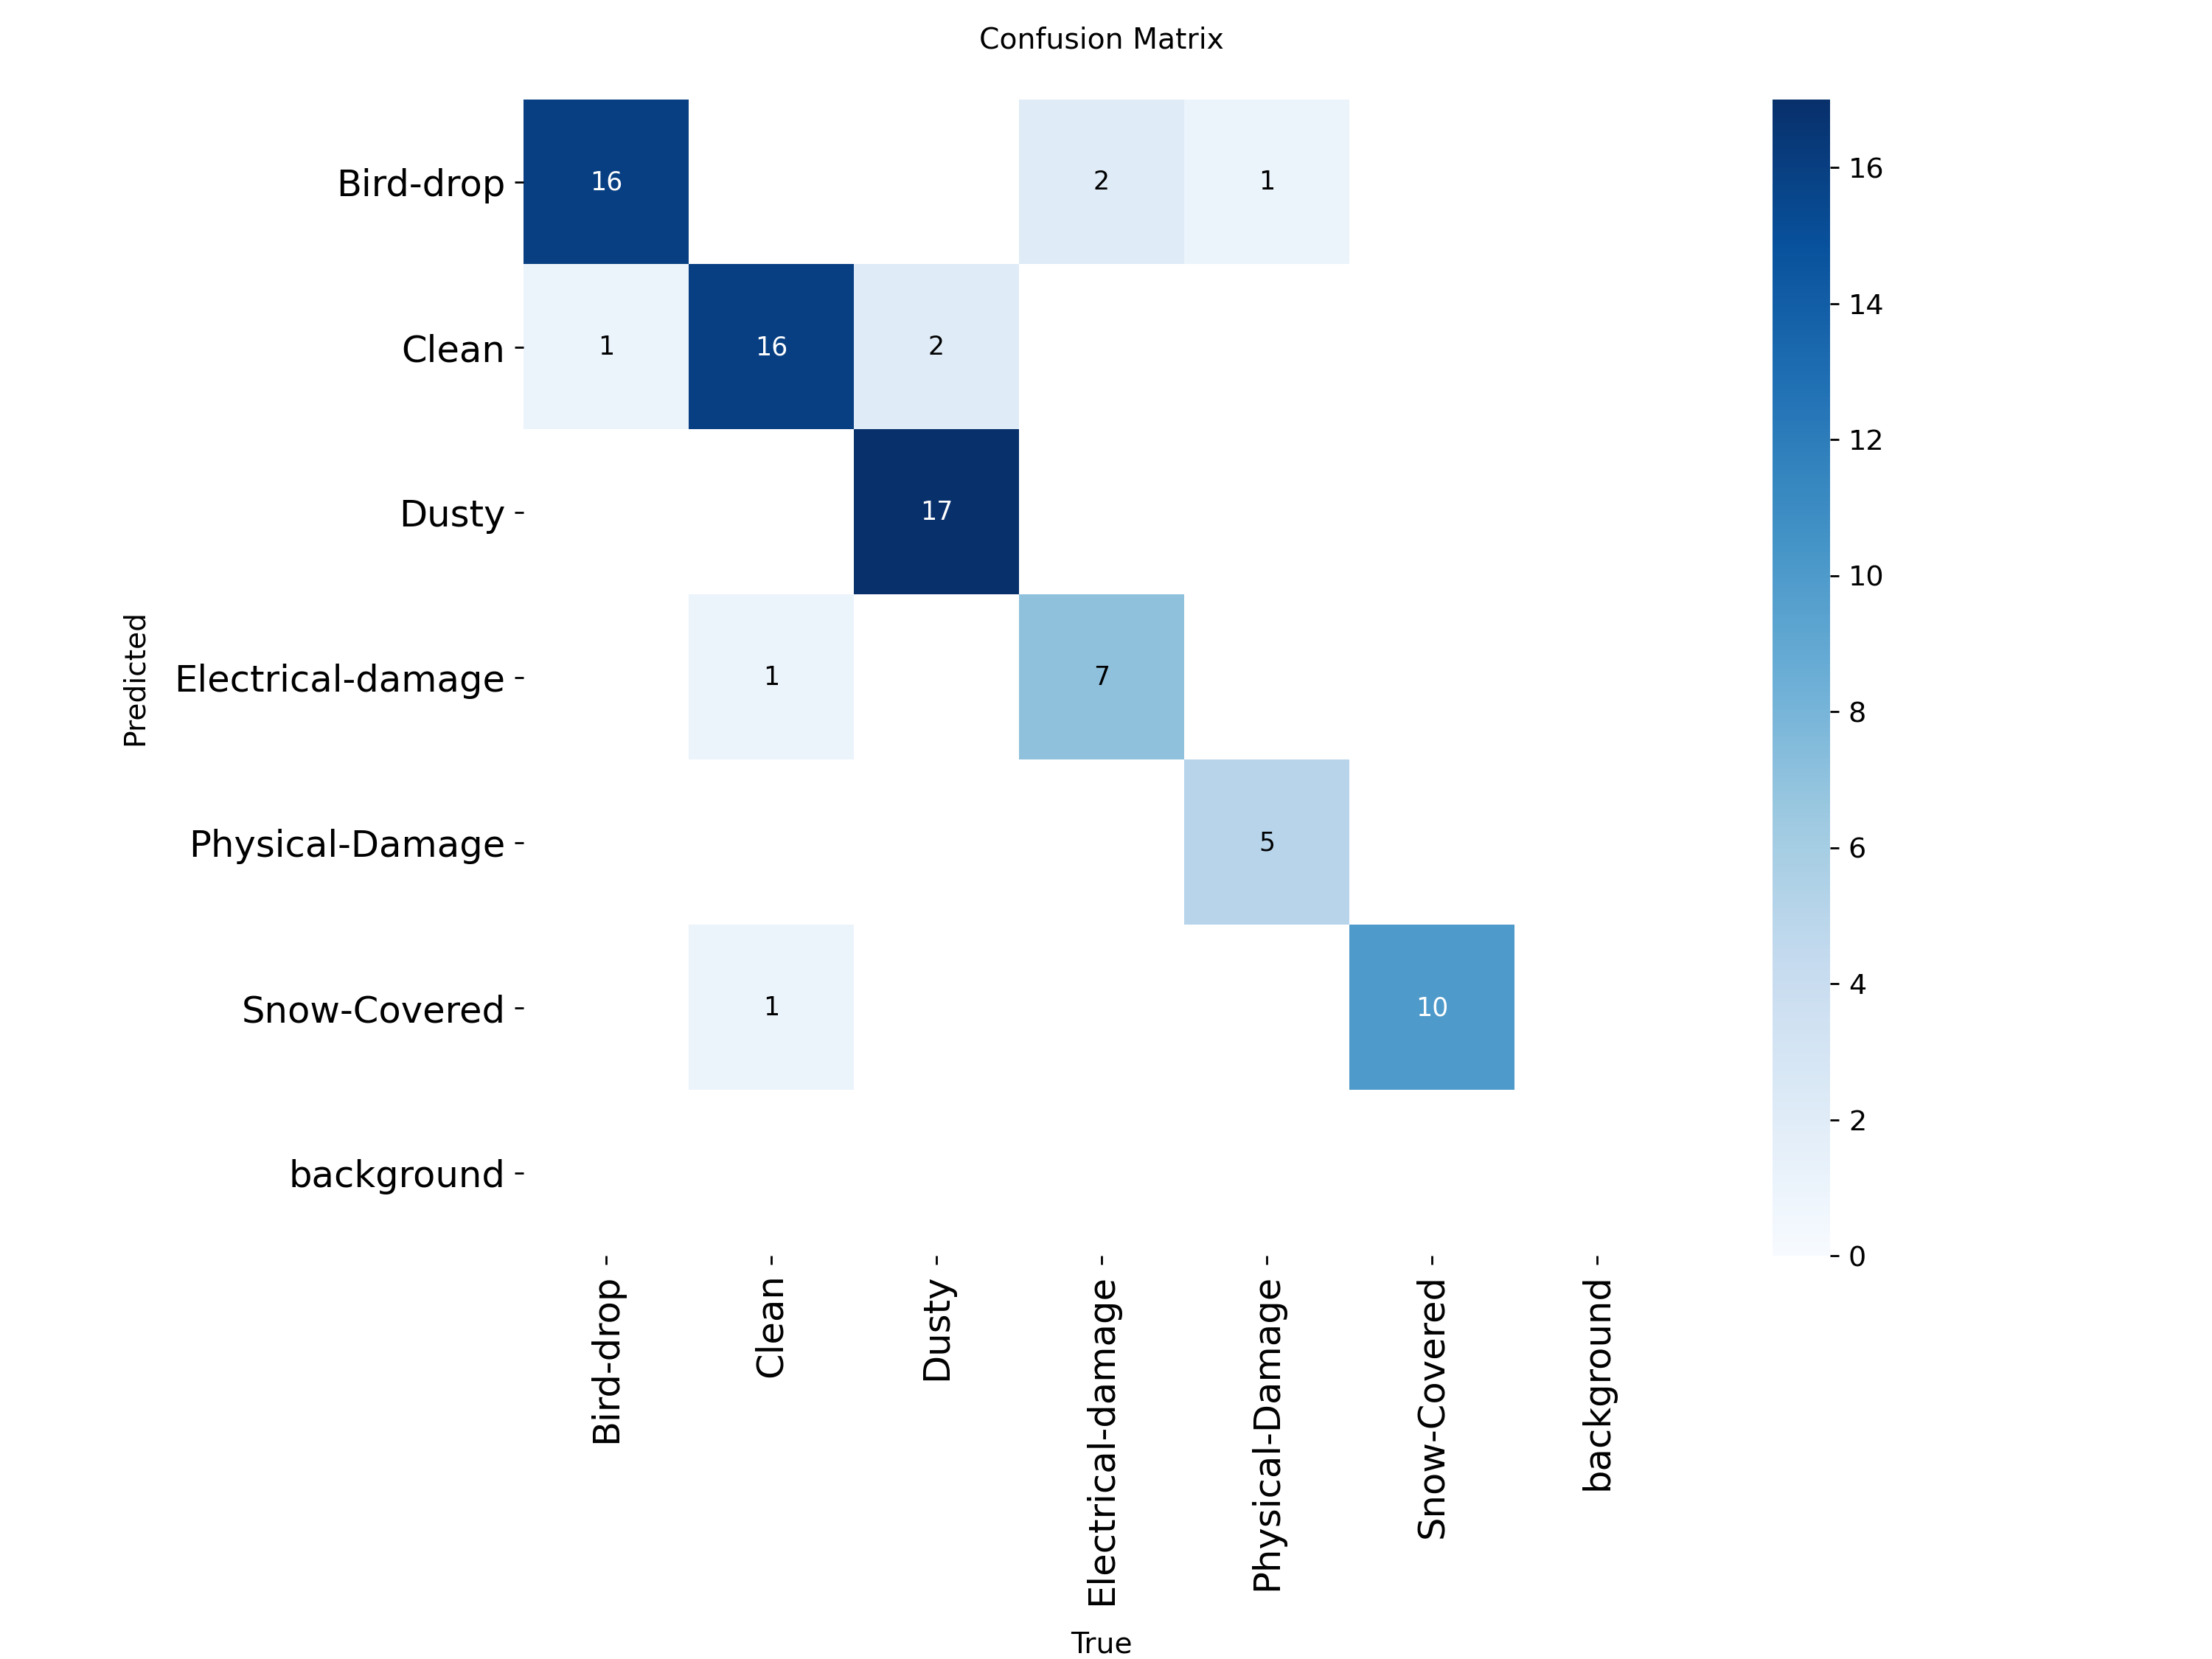

Bird (104).jpg: true=Bird-drop pred=Bird-drop conf=1.00 [CORRECT]


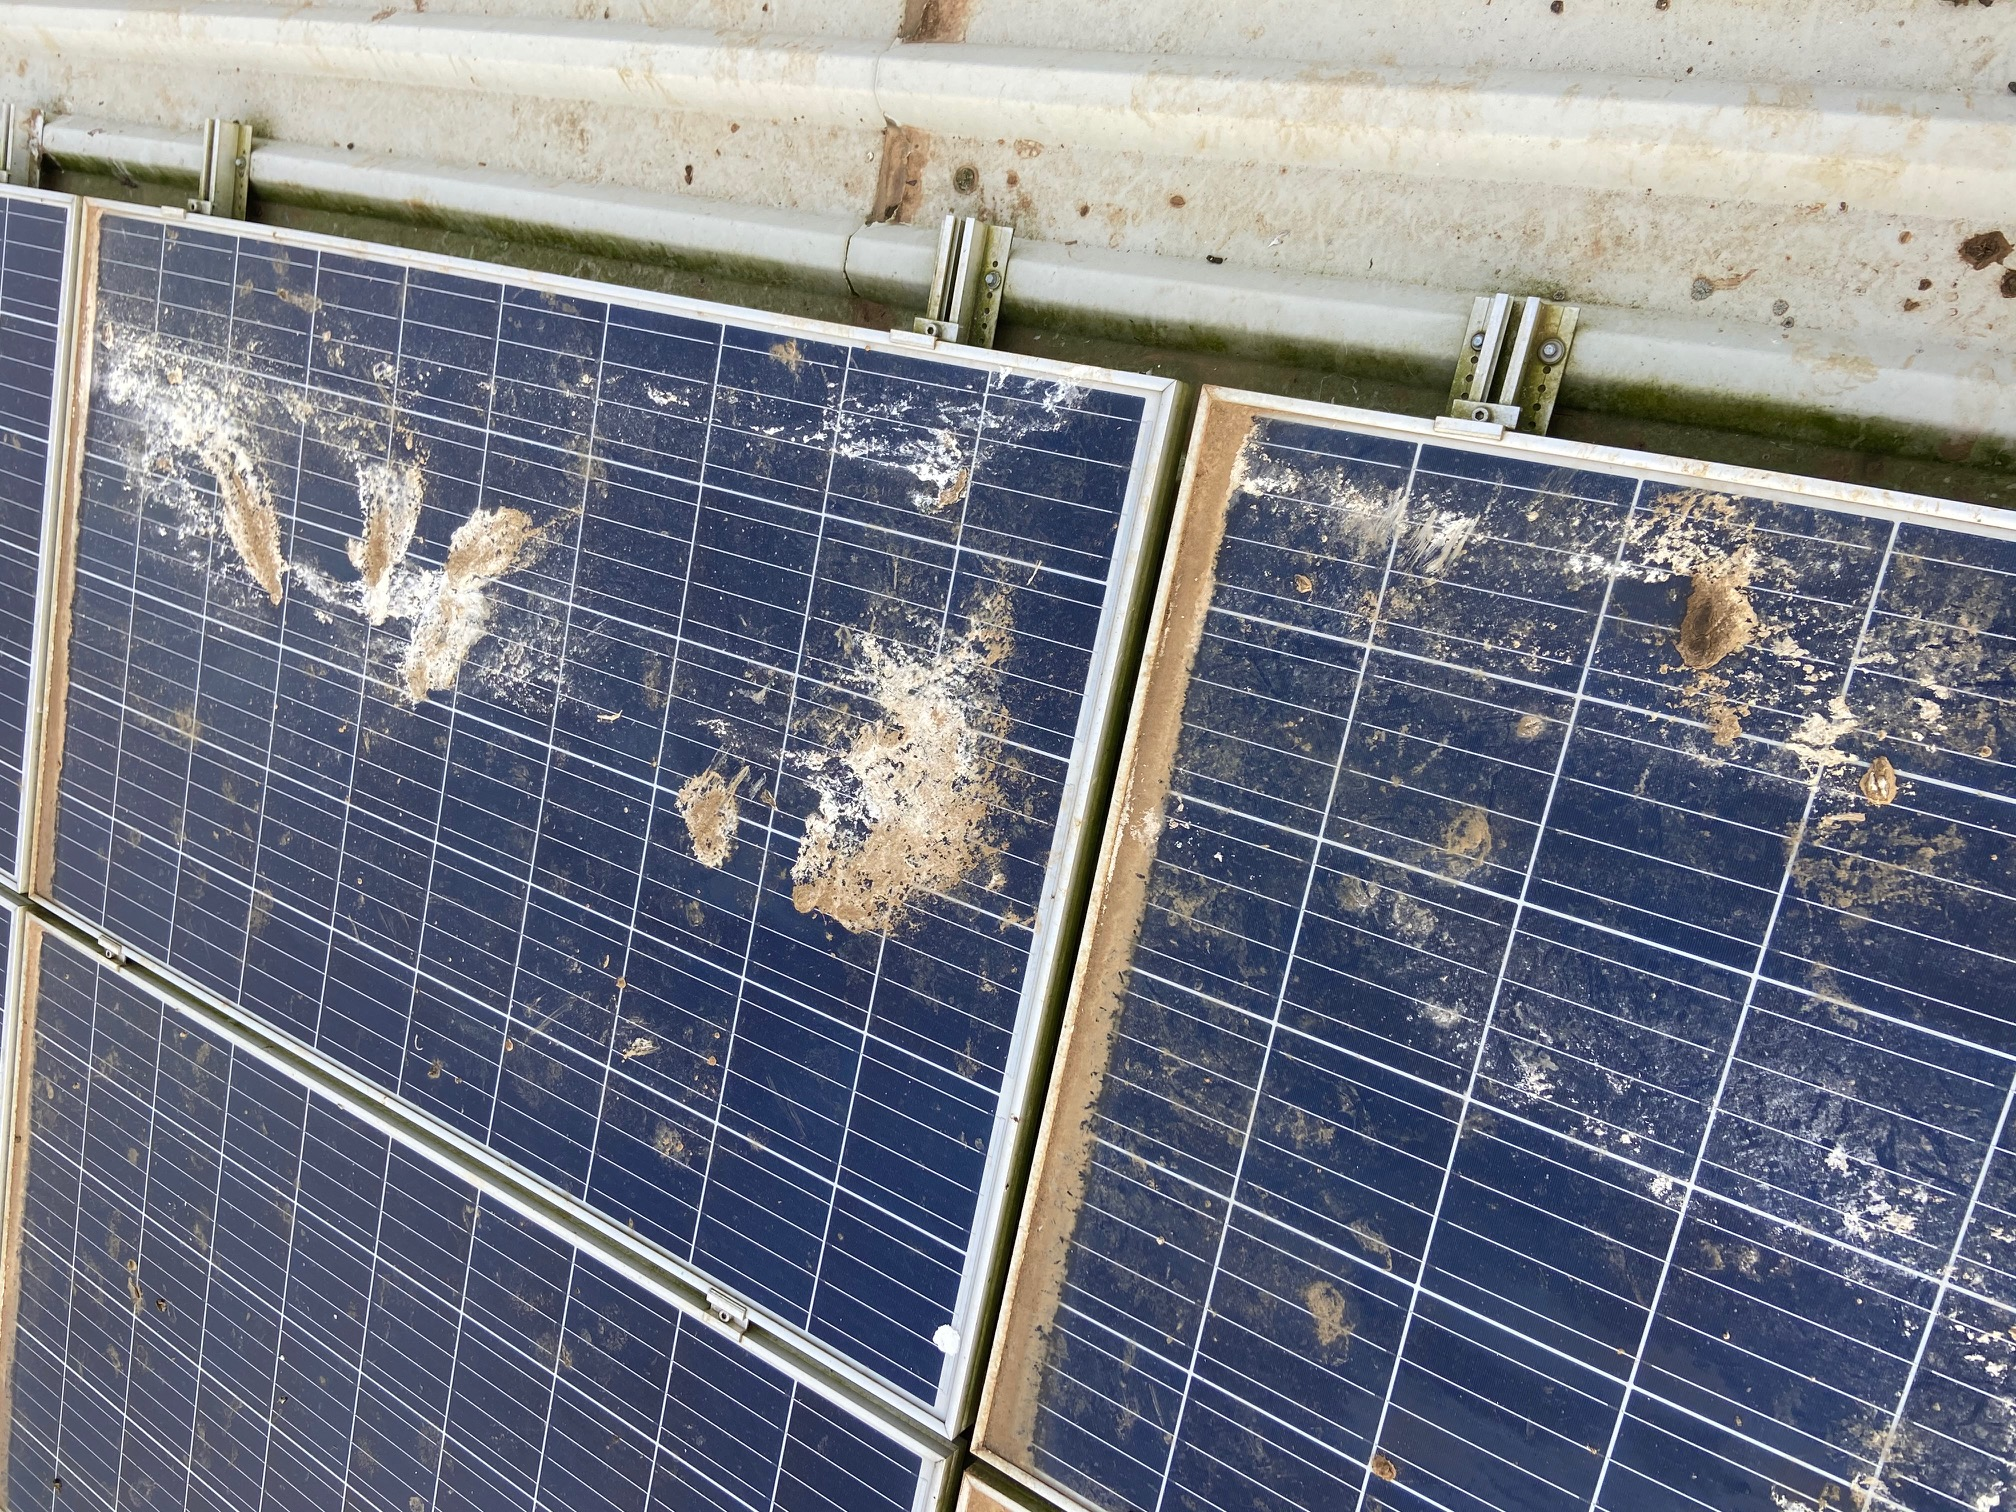

Bird (118).jpg: true=Bird-drop pred=Bird-drop conf=1.00 [CORRECT]


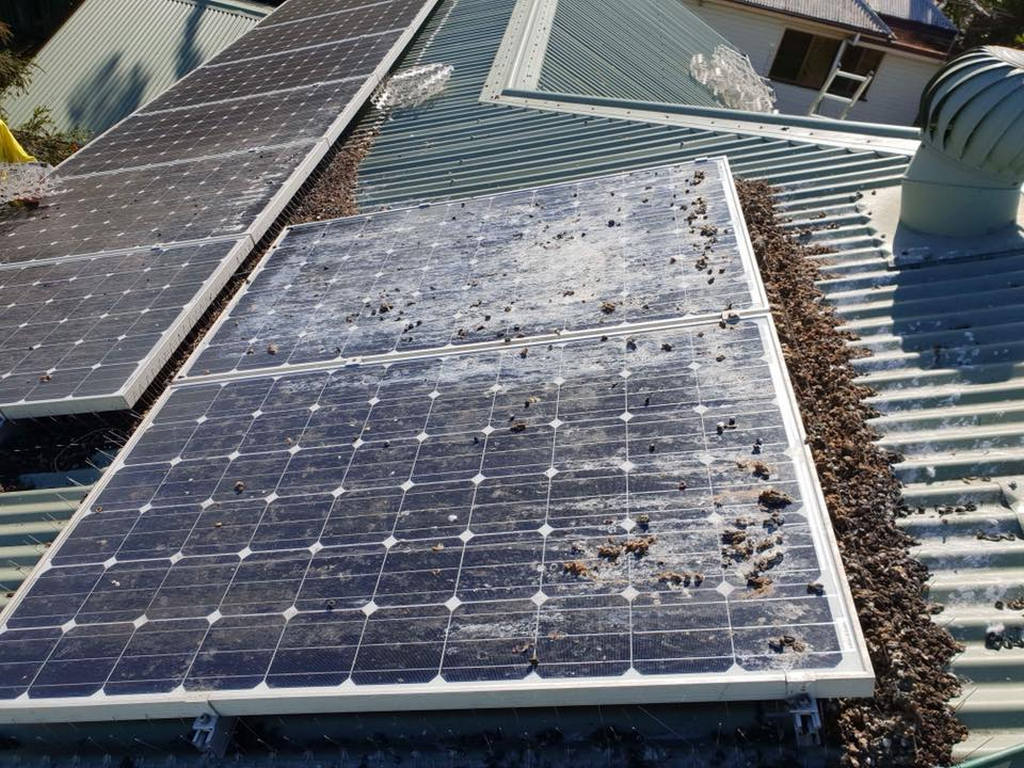

Bird (125).jpg: true=Bird-drop pred=Bird-drop conf=1.00 [CORRECT]


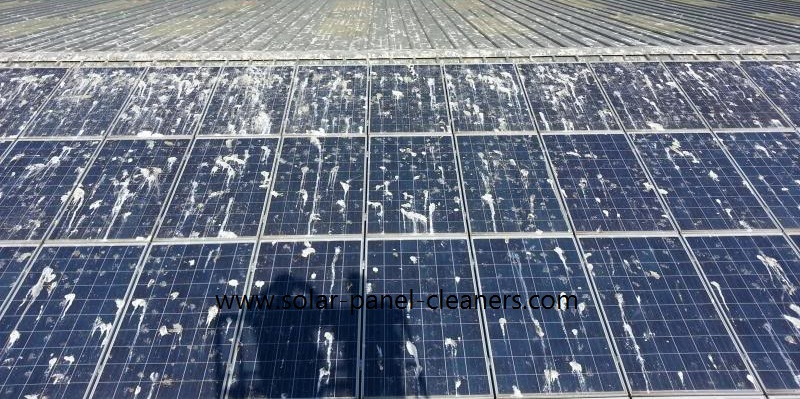

Bird (133).jpg: true=Bird-drop pred=Bird-drop conf=1.00 [CORRECT]


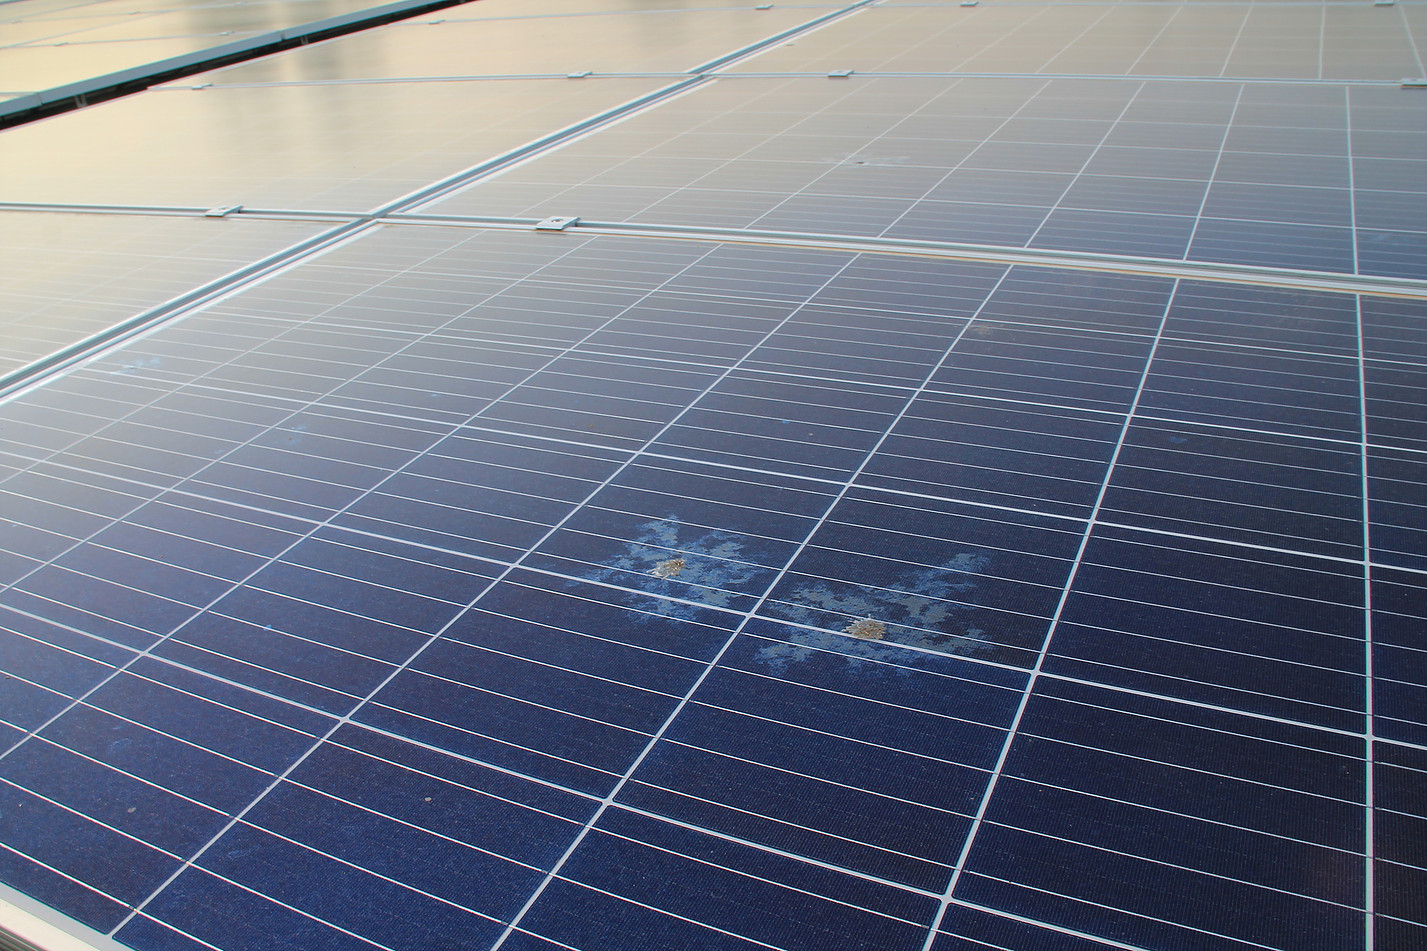

In [4]:
# ── CELL 4: Evaluate + visualise ──────────────────────────────────
from ultralytics import YOLO
from IPython.display import Image as IPImg, display
from pathlib import Path
import glob

BEST = '/kaggle/working/models/surface_defect_v1/weights/best.pt'
model = YOLO(BEST)

metrics = model.val(data='/kaggle/working/surface_defects_split', split='test')
print(f'Top-1 Accuracy: {metrics.top1:.4f}')
print(f'Top-5 Accuracy: {metrics.top5:.4f}')

# Training curves
run_dir = Path('/kaggle/working/models/surface_defect_v1')
for p in ['results.png', 'confusion_matrix.png']:
    fp = run_dir / p
    if fp.exists():
        print(f'\n{p}:')
        display(IPImg(str(fp), width=700))

# Sample predictions
test_imgs = sorted(glob.glob('/kaggle/working/surface_defects_split/test/*/*.jpg'))[:4]
for img_path in test_imgs:
    r = model.predict(img_path, verbose=False)[0]
    pred = model.names[int(r.probs.top1)]
    conf = float(r.probs.top1conf)
    true_label = Path(img_path).parent.name
    match = 'CORRECT' if pred == true_label else 'WRONG'
    print(f'{Path(img_path).name}: true={true_label} pred={pred} conf={conf:.2f} [{match}]')
    display(IPImg(img_path, width=300))

In [5]:
# ── CELL 5: Export weights ────────────────────────────────────────
import shutil
from pathlib import Path
from ultralytics import YOLO

BEST       = Path('/kaggle/working/models/surface_defect_v1/weights/best.pt')
EXPORT_DIR = Path('/kaggle/working/exports')
EXPORT_DIR.mkdir(exist_ok=True)

model = YOLO(str(BEST))

pt_out = EXPORT_DIR / 'surface_defect_best.pt'
shutil.copy(BEST, pt_out)
print(f'[OK] PyTorch: {pt_out} ({pt_out.stat().st_size/1e6:.1f}MB)')
print('     -> Use in step4_combined_api_server.py: MODEL_SURFACE=surface_defect_best.pt')

print('\nExporting ONNX...')
try:
    onnx = model.export(format='onnx', imgsz=224, simplify=True)
    onnx_out = EXPORT_DIR / 'surface_defect.onnx'
    shutil.copy(onnx, onnx_out)
    print(f'[OK] ONNX: {onnx_out} ({onnx_out.stat().st_size/1e6:.1f}MB)')
except Exception as e:
    print(f'[WARN] ONNX export failed: {e}')

print('\nDownload from: right sidebar -> Output -> exports/')

[OK] PyTorch: /kaggle/working/exports/surface_defect_best.pt (3.0MB)
     -> Use in step4_combined_api_server.py: MODEL_SURFACE=surface_defect_best.pt

Exporting ONNX...
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-cls summary (fused): 30 layers, 1,442,566 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/kaggle/working/models/surface_defect_v1/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 6) (2.8 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 312ms
Prepared 2 packages in 311ms
Installed 2 packages in 17ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart 